# Price Prediction - Neural Network

Let's start by importing necessary packages.

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score

Now read in the dataframe and prepare it for use in `pytorch`.

In [3]:
df = pd.read_parquet("../all_car_details_cleaned.parquet")

## Prepare for Use in NN

### Drop unnecessary columns

In [4]:
columns_to_drop = [
    "url",
    "num_images",
    "general_inspection",
    "emission_class",
    "comfort_and_convenience",
    "safety_and_security",
    "entertainment_and_media",
    "extras",
    "paint",
]


df.drop(columns=columns_to_drop, errors="ignore", inplace=True)

### Transform columns

Transform values that are not stored as numerical, but are technically numerical.

In [5]:
df["doors"] = pd.to_numeric(df["doors"], errors="coerce")
df["seats"] = pd.to_numeric(df["seats"], errors="coerce")
df["gears"] = pd.to_numeric(df["gears"], errors="coerce")
df["cylinders"] = pd.to_numeric(df["cylinders"], errors="coerce")

### Split Train - Validate - Test

In [6]:
# Separate Features X and Target Y
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)  # 0.5 * 0.3 = 0.15

print("Shapes of the splits:")
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape, "y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

Shapes of the splits:
X_train shape: (327703, 25) y_train shape: (327703,)
X_val shape: (70222, 25) y_val shape: (70222,)
X_test shape: (70223, 25) y_test shape: (70223,)


### Feature Selection

Let's check the correlation of numerical features with `price` to see which features are useless in this regard.

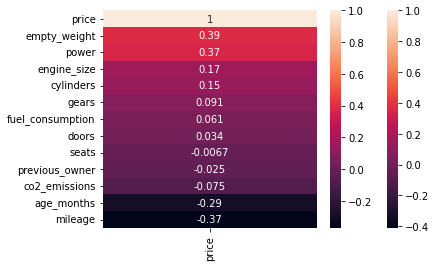

In [7]:
train_df_for_corr = X_train.copy()
train_df_for_corr['price'] = y_train

corr_matrix_train = train_df_for_corr.corr(numeric_only=True)
sns.heatmap(corr_matrix_train) # Visualize if needed
sns.heatmap(corr_matrix_train[['price']].sort_values(by="price", ascending=False), annot=True)
plt.show()

Evidently, `gears`, `fuel_consumption`, `doors`, `seats`, `co2_emissions` are not at really related to the price of the car, it is probably safe to assume we can drop these columns as there is no likely combination these features that correlate with price. Moreover, it is also benefitial to drop them due to the greater portion of missing values these columns have.

In [8]:
columns_to_drop = ["gears", "fuel_consumption", "doors", "seats", "co2_emissions"]

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_val = X_val.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print("X_train shape after numeric FS:", X_train.shape)

X_train shape after numeric FS: (327703, 20)


Now let's check the usefulness of our categorical variables using `Mutual Information`.

- Higher MI scores (closer to 1) indicate stronger relationships with price
- Very low scores (close to 0) suggest the feature might not be useful

In [9]:
# First, identify categorical columns (excluding the ones we know we want to drop)
categorical_cols_fs = X_train.select_dtypes(include=["object"]).columns.tolist()
mi_scores_train = {}

if categorical_cols_fs:  # Ensure there are categorical columns to process
    for column in categorical_cols_fs:
        le_fs = LabelEncoder()
        # Fit LabelEncoder only on X_train for this specific MI calculation
        # Handle missing values temporarily for MI calculation if any exist in X_train[column]
        train_column_data = X_train[column].fillna("missing_for_mi")
        encoded_train_column = le_fs.fit_transform(train_column_data)
        mi_score = mutual_info_regression(
            encoded_train_column.reshape(-1, 1), y_train, discrete_features=True
        )[0]
        mi_scores_train[column] = mi_score

    mi_df_train = pd.DataFrame.from_dict(
        mi_scores_train, orient="index", columns=["MI_score"]
    )
    mi_df_train = mi_df_train.sort_values("MI_score", ascending=False)
    print("Mutual Information scores for categorical features (from training data):")
    print(mi_df_train)

Mutual Information scores for categorical features (from training data):
                      MI_score
car_title             1.198672
make                  0.586269
location              0.332248
body_type             0.262905
gearbox               0.225353
seller                0.203649
drivetrain            0.202383
fuel_type             0.191034
upholstery            0.176510
used_type             0.140383
exterior_colour       0.107587
upholstery_colour     0.086650
full_service_history  0.048535


It seems like `full_service_history` and `upholstery_colour` are useless features, let's remove these.

In [10]:
# Decide columns_to_drop_categorical based on mi_df_train
columns_to_drop_categorical = ["full_service_history", "upholstery_colour"] # Your original list

# Drop these columns from all splits
X_train = X_train.drop(columns=columns_to_drop_categorical, errors="ignore")
X_val = X_val.drop(columns=columns_to_drop_categorical, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop_categorical, errors="ignore")

print("X_train shape after categorical FS:", X_train.shape)

X_train shape after categorical FS: (327703, 18)


### Handle Missing Values

We can not have missing values in Neural Network datasets, so let's deal with them. I will approach this in the following ways, creating a seprate dataframe for each of them:

- drop all missing values all around, but also remove `upholstery`, `exterior_colour`, as these have comparatively many missing values and little explaining power
- impute all missing values with a method appropriate for the given feature - `media` or `Unknoown`
- impute all data with the method we have found in a scientific paper, using `IterativeImputer`, `ExtraTreesRegressor`

#### Dropping Values

In [11]:
# Drop columns
# Create copies from the feature-selected X_train, X_val, X_test
X_train_dropped = X_train.copy()
X_val_dropped = X_val.copy()
X_test_dropped = X_test.copy()

# Also create copies of y_train, y_val, y_test to align them after dropping rows
y_train_dropped = y_train.copy()
y_val_dropped = y_val.copy()
y_test_dropped = y_test.copy()

print("Initial shapes for _dropped path:")
print("X_train_dropped shape:", X_train_dropped.shape)
print("X_val_dropped shape:", X_val_dropped.shape)
print("X_test_dropped shape:", X_test_dropped.shape)

columns_to_specifically_drop_for_dropped_path = ["upholstery", "exterior_colour"]
X_train_dropped.drop(columns=columns_to_specifically_drop_for_dropped_path, errors="ignore", inplace=True)
X_val_dropped.drop(columns=columns_to_specifically_drop_for_dropped_path, errors="ignore", inplace=True)
X_test_dropped.drop(columns=columns_to_specifically_drop_for_dropped_path, errors="ignore", inplace=True)

print("\nShapes after dropping 'upholstery', 'exterior_colour':")
print("X_train_dropped shape:", X_train_dropped.shape)

# Apply dropna() to each split and align y
X_train_dropped.dropna(inplace=True)
y_train_dropped = y_train_dropped.loc[X_train_dropped.index]

X_val_dropped.dropna(inplace=True)
y_val_dropped = y_val_dropped.loc[X_val_dropped.index]

X_test_dropped.dropna(inplace=True)
y_test_dropped = y_test_dropped.loc[X_test_dropped.index]

print("\nShapes after dropna():")
print("X_train_dropped shape:", X_train_dropped.shape, "y_train_dropped shape:", y_train_dropped.shape)
print("X_val_dropped shape:", X_val_dropped.shape, "y_val_dropped shape:", y_val_dropped.shape)
print("X_test_dropped shape:", X_test_dropped.shape, "y_test_dropped shape:", y_test_dropped.shape)


Initial shapes for _dropped path:
X_train_dropped shape: (327703, 18)
X_val_dropped shape: (70222, 18)
X_test_dropped shape: (70223, 18)

Shapes after dropping 'upholstery', 'exterior_colour':
X_train_dropped shape: (327703, 16)

Shapes after dropna():
X_train_dropped shape: (151373, 16) y_train_dropped shape: (151373,)
X_val_dropped shape: (32324, 16) y_val_dropped shape: (32324,)
X_test_dropped shape: (32397, 16) y_test_dropped shape: (32397,)


This seems to have removed a significant portion of our dataset as expected, but we will see if it works better than our imputed one.

#### Imputing values

Numerical values will simply be imputed with their medians, this applies to `engine_size`, `cylinders`, `empty_weight`.

Categorical missing values will get filled with `Unknown`.

In [12]:
X_train_imputed = X_train.copy()
X_val_imputed = X_val.copy()
X_test_imputed = X_test.copy()

# First, check which columns actually have missing values
original_shape = X_train_imputed.shape
print("Columns with missing values before:")
print(X_train_imputed.isnull().sum()[X_train_imputed.isnull().sum() > 0])

# Identify numerical and categorical columns from X_train_imputed
numerical_cols_impute = X_train_imputed.select_dtypes(
    include=["float64", "int64"]
).columns.tolist()
categorical_cols_impute = X_train_imputed.select_dtypes(
    include=["object"]
).columns.tolist()

# 1. Categorical Imputation: Fill with 'Unknown'
for col in categorical_cols_impute:
    X_train_imputed[col] = X_train_imputed[col].fillna("Unknown")
    X_val_imputed[col] = X_val_imputed[col].fillna("Unknown")
    X_test_imputed[col] = X_test_imputed[col].fillna("Unknown")

# 2. Numerical Imputation: Fit imputer on X_train_imputed, transform all
if numerical_cols_impute:  # Check if there are numerical columns
    numerical_imputer = SimpleImputer(strategy="median")

    # Fit the imputer ONLY on X_train_imputed numerical columns
    X_train_imputed[numerical_cols_impute] = numerical_imputer.fit_transform(
        X_train_imputed[numerical_cols_impute]
    )

    # Transform X_val_imputed and X_test_imputed numerical columns
    X_val_imputed[numerical_cols_impute] = numerical_imputer.transform(
        X_val_imputed[numerical_cols_impute]
    )
    X_test_imputed[numerical_cols_impute] = numerical_imputer.transform(
        X_test_imputed[numerical_cols_impute]
    )

# Verify results
print("\nMissing values after imputation:")
print(
    X_train_imputed.isnull().sum()[X_train_imputed.isnull().sum() > 0]
)  # Should be empty

# Also check the shapes to ensure no data was lost
print("\nOriginal shape:", original_shape)
print("Imputed shape:", X_train_imputed.shape)

Columns with missing values before:
seller               3946
body_type               2
drivetrain         102323
gearbox              6379
engine_size         46129
cylinders           90511
empty_weight        91654
fuel_type             691
exterior_colour     39966
upholstery         104547
dtype: int64

Missing values after imputation:
Series([], dtype: int64)

Original shape: (327703, 18)
Imputed shape: (327703, 18)


### Handle High Cardinality Categorical Variables

Some features, namely `make` and `car_title` have a very high cardinality, `223` and `2840` respectively, we have to try and keep these down even if we wind up using `embeddings` over `one-hot encoding`.

I have decided that I will be using a 0.05% grouping threshold for `make` and a 0.025% grouping threshold for `car_title`, these in the imputed set equal to - 47 and 23 records minimum respectively.

In [13]:
print("Unique makes before: ", X_train_imputed["make"].nunique())
print("Unique titles before: ", X_train_imputed["car_title"].nunique())

make_threshold = 0.0001 # Example, adjust as needed
title_threshold = 0.00005 # Example, adjust as needed

print(
    f"\nGrouping with thresholds: \n- make: {make_threshold} ({round(make_threshold * X_train_imputed.shape[0])})\n- title: {title_threshold} ({round(title_threshold * X_train_imputed.shape[0])})"
)

def get_rare_categories(series, threshold):
    value_counts = series.value_counts(normalize=True)
    return value_counts[value_counts < threshold].index

# Group 'make'
rare_makes_train = get_rare_categories(X_train_imputed['make'], make_threshold)
X_train_imputed['make'] = X_train_imputed['make'].apply(lambda x: 'Other' if x in rare_makes_train else x)
X_val_imputed['make'] = X_val_imputed['make'].apply(lambda x: 'Other' if x in rare_makes_train else x) # Use rare_makes_train
X_test_imputed['make'] = X_test_imputed['make'].apply(lambda x: 'Other' if x in rare_makes_train else x) # Use rare_makes_train

# Group 'car_title'
rare_titles_train = get_rare_categories(X_train_imputed['car_title'], title_threshold)
X_train_imputed['car_title'] = X_train_imputed['car_title'].apply(lambda x: 'Other' if x in rare_titles_train else x)
X_val_imputed['car_title'] = X_val_imputed['car_title'].apply(lambda x: 'Other' if x in rare_titles_train else x) # Use rare_titles_train
X_test_imputed['car_title'] = X_test_imputed['car_title'].apply(lambda x: 'Other' if x in rare_titles_train else x) # Use rare_titles_train


print("\nUnique makes after: ", X_train_imputed["make"].nunique())
print("Unique titles after: ", X_train_imputed["car_title"].nunique())

Unique makes before:  216
Unique titles before:  2717

Grouping with thresholds: 
- make: 0.0001 (33)
- title: 5e-05 (16)

Unique makes after:  110
Unique titles after:  1353


This leads us with `109 makes` and `1352 unique car titles` which is significantly less, about half as much as our previous counts. Now let's do the same for `df_dropped`.

In [14]:
print("Unique makes before: ", X_train_dropped["make"].nunique())
print("Unique titles before: ", X_train_dropped["car_title"].nunique())

make_threshold = 0.0001 # Example, adjust as needed
title_threshold = 0.00005 # Example, adjust as needed

print(
    f"\nGrouping with thresholds: \n- make: {make_threshold} ({round(make_threshold * X_train_dropped.shape[0])})\n- title: {title_threshold} ({round(title_threshold * X_train_imputed.shape[0])})"
)

def get_rare_categories(series, threshold):
    value_counts = series.value_counts(normalize=True)
    return value_counts[value_counts < threshold].index

# Group 'make'
rare_makes_train = get_rare_categories(X_train_dropped['make'], make_threshold)
X_train_dropped['make'] = X_train_dropped['make'].apply(lambda x: 'Other' if x in rare_makes_train else x)
X_val_dropped['make'] = X_val_dropped['make'].apply(lambda x: 'Other' if x in rare_makes_train else x) # Use rare_makes_train
X_test_dropped['make'] = X_test_dropped['make'].apply(lambda x: 'Other' if x in rare_makes_train else x) # Use rare_makes_train

# Group 'car_title'
rare_titles_train = get_rare_categories(X_train_dropped['car_title'], title_threshold)
X_train_dropped['car_title'] = X_train_dropped['car_title'].apply(lambda x: 'Other' if x in rare_titles_train else x)
X_val_dropped['car_title'] = X_val_dropped['car_title'].apply(lambda x: 'Other' if x in rare_titles_train else x) # Use rare_titles_train
X_test_dropped['car_title'] = X_test_dropped['car_title'].apply(lambda x: 'Other' if x in rare_titles_train else x) # Use rare_titles_train


print("\nUnique makes after: ", X_train_dropped["make"].nunique())
print("Unique titles after: ", X_train_dropped["car_title"].nunique())

Unique makes before:  166
Unique titles before:  2066

Grouping with thresholds: 
- make: 0.0001 (15)
- title: 5e-05 (16)

Unique makes after:  93
Unique titles after:  1117


Doing the same grouping seems to lead to a similar outcome, albeit a little less distinct values in both cases.

### Label Encode - `make` and `car_title`

Now let's encode the values.

In [15]:
# Label encode Make and Car title
le_make_imputed = LabelEncoder()
# Fit encoder ONLY on X_train_imputed['make']
X_train_imputed['make_encoded'] = le_make_imputed.fit_transform(X_train_imputed['make'])

def transform_with_le(series, encoder, unknown_label='Other'):
    # Get the encoding for the unknown_label, if it exists in the encoder's classes
    try:
        unknown_encoding = encoder.transform([unknown_label])[0]
    except ValueError: # 'Other' might not be in classes_ if no values were mapped to it in train
        transformed_series = series.copy()
        for i, val in enumerate(series):
            if val not in encoder.classes_:
                transformed_series.iloc[i] = unknown_label # Map to 'Other'
        return encoder.transform(transformed_series)
    
    # Apply transformation, mapping unknowns to 'Other'
    transformed_values = []
    for val in series:
        if val in encoder.classes_:
            transformed_values.append(encoder.transform([val])[0])
        else:
            transformed_values.append(unknown_encoding) # Map to 'Other's encoding
    return transformed_values


X_val_imputed['make_encoded'] = transform_with_le(X_val_imputed['make'], le_make_imputed)
X_test_imputed['make_encoded'] = transform_with_le(X_test_imputed['make'], le_make_imputed)


# For 'car_title'
le_car_title_imputed = LabelEncoder()
X_train_imputed['car_title_encoded'] = le_car_title_imputed.fit_transform(X_train_imputed['car_title'])
X_val_imputed['car_title_encoded'] = transform_with_le(X_val_imputed['car_title'], le_car_title_imputed)
X_test_imputed['car_title_encoded'] = transform_with_le(X_test_imputed['car_title'], le_car_title_imputed)

# Drop original 'make' and 'car_title' columns
X_train_imputed = X_train_imputed.drop(columns=['make', 'car_title'])
X_val_imputed = X_val_imputed.drop(columns=['make', 'car_title'])
X_test_imputed = X_test_imputed.drop(columns=['make', 'car_title'])

print("\nShapes after label encoding for _imputed path:")
print("X_train_imputed shape:", X_train_imputed.shape)
print("X_val_imputed shape:", X_val_imputed.shape)
print("X_test_imputed shape:", X_test_imputed.shape)


Shapes after label encoding for _imputed path:
X_train_imputed shape: (327703, 18)
X_val_imputed shape: (70222, 18)
X_test_imputed shape: (70223, 18)


In [16]:
# Label encode Make and Car title for the _dropped dataframes
# Fit encoder ONLY on X_train_dropped['make']
le_make_dropped = LabelEncoder()
X_train_dropped['make_encoded'] = le_make_dropped.fit_transform(X_train_dropped['make'])

# Use the transform_with_le function for val and test sets
X_val_dropped['make_encoded'] = transform_with_le(X_val_dropped['make'], le_make_dropped)
X_test_dropped['make_encoded'] = transform_with_le(X_test_dropped['make'], le_make_dropped)

# For 'car_title'
le_car_title_dropped = LabelEncoder()
X_train_dropped['car_title_encoded'] = le_car_title_dropped.fit_transform(X_train_dropped['car_title'])

# Use the transform_with_le function for val and test sets
X_val_dropped['car_title_encoded'] = transform_with_le(X_val_dropped['car_title'], le_car_title_dropped)
X_test_dropped['car_title_encoded'] = transform_with_le(X_test_dropped['car_title'], le_car_title_dropped)

# Drop original 'make' and 'car_title' columns from _dropped dataframes
X_train_dropped = X_train_dropped.drop(columns=['make', 'car_title'])
X_val_dropped = X_val_dropped.drop(columns=['make', 'car_title'])
X_test_dropped = X_test_dropped.drop(columns=['make', 'car_title'])

print("\nShapes after label encoding for _dropped path:")
print("X_train_dropped shape:", X_train_dropped.shape)
print("X_val_dropped shape:", X_val_dropped.shape)
print("X_test_dropped shape:", X_test_dropped.shape)


Shapes after label encoding for _dropped path:
X_train_dropped shape: (151373, 16)
X_val_dropped shape: (32324, 16)
X_test_dropped shape: (32397, 16)


### Scale and OHE

In [17]:
def preprocess_data_for_nn(X_train_df, X_val_df, X_test_df, df_path_name=""):
    print(f"\n--- Preprocessing Data for {df_path_name} Path ---")

    # Create copies to avoid modifying original dataframes passed to the function
    X_train = X_train_df.copy()
    X_val = X_val_df.copy()
    X_test = X_test_df.copy()

    # Define original numerical columns that need scaling
    # These are the ones that were actual numbers before any encoding
    numerical_cols_to_scale = [
        'mileage', 'previous_owner', 'power', 'engine_size',
        'cylinders', 'empty_weight', 'age_months'
    ]
    # Filter this list to include only columns currently present in X_train
    numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col in X_train.columns]

    # Define categorical columns for one-hot encoding
    # These are columns with 'object' dtype at this stage
    categorical_cols_to_ohe = X_train.select_dtypes(include=['object']).columns.tolist()

    # Define label-encoded columns that should be passed through
    label_encoded_passthrough_cols = ['make_encoded', 'car_title_encoded']
    # Filter this list for presence in X_train
    label_encoded_passthrough_cols = [col for col in label_encoded_passthrough_cols if col in X_train.columns]

    print(f"Numerical columns to scale: {numerical_cols_to_scale}")
    print(f"Categorical columns to OHE: {categorical_cols_to_ohe}")
    print(f"Label-encoded columns to passthrough: {label_encoded_passthrough_cols}")

    transformers_list = []
    if numerical_cols_to_scale:
        transformers_list.append(('num', StandardScaler(), numerical_cols_to_scale))
    if categorical_cols_to_ohe:
        transformers_list.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_cols_to_ohe))
    if label_encoded_passthrough_cols:
        # Ensure these passthrough columns are not also in other lists
        # (they shouldn't be if 'make' and 'car_title' were already dropped and replaced by _encoded versions)
        transformers_list.append(('le_passthrough', 'passthrough', label_encoded_passthrough_cols))
    
    preprocessor = ColumnTransformer(
        transformers=transformers_list,
        remainder='drop'  # Drops any columns not specified (should be none if lists are correct)
    )

    # Fit preprocessor on X_train and transform all sets
    X_train_processed_np = preprocessor.fit_transform(X_train)
    X_val_processed_np = preprocessor.transform(X_val)
    X_test_processed_np = preprocessor.transform(X_test)

    # Get feature names after transformation
    # ColumnTransformer.get_feature_names_out() is great for this
    feature_names = preprocessor.get_feature_names_out()

    # Convert back to DataFrames
    X_train_processed = pd.DataFrame(X_train_processed_np, columns=feature_names, index=X_train.index)
    X_val_processed = pd.DataFrame(X_val_processed_np, columns=feature_names, index=X_val.index)
    X_test_processed = pd.DataFrame(X_test_processed_np, columns=feature_names, index=X_test.index)

    print("Shapes after preprocessing:")
    print(f"X_train_{df_path_name.lower()}_processed shape: {X_train_processed.shape}")
    print(f"X_val_{df_path_name.lower()}_processed shape: {X_val_processed.shape}")
    print(f"X_test_{df_path_name.lower()}_processed shape: {X_test_processed.shape}")
    print(f"First 5 rows of X_train_{df_path_name.lower()}_processed head:")
    print(X_train_processed.head())

    return X_train_processed, X_val_processed, X_test_processed

# Apply to the imputed path:
# These inputs (X_train_imputed, etc.) are from after label encoding 'make' and 'car_title'
X_train_imputed_processed, X_val_imputed_processed, X_test_imputed_processed = preprocess_data_for_nn(
    X_train_imputed, X_val_imputed, X_test_imputed, df_path_name="Imputed"
)

# Apply to the dropped path:
# These inputs (X_train_dropped, etc.) are from after label encoding 'make' and 'car_title'
X_train_dropped_processed, X_val_dropped_processed, X_test_dropped_processed = preprocess_data_for_nn(
    X_train_dropped, X_val_dropped, X_test_dropped, df_path_name="Dropped"
)


--- Preprocessing Data for Imputed Path ---
Numerical columns to scale: ['mileage', 'previous_owner', 'power', 'engine_size', 'cylinders', 'empty_weight', 'age_months']
Categorical columns to OHE: ['seller', 'location', 'body_type', 'used_type', 'drivetrain', 'gearbox', 'fuel_type', 'exterior_colour', 'upholstery']
Label-encoded columns to passthrough: ['make_encoded', 'car_title_encoded']
Shapes after preprocessing:
X_train_imputed_processed shape: (327703, 99)
X_val_imputed_processed shape: (70222, 99)
X_test_imputed_processed shape: (70223, 99)
First 5 rows of X_train_imputed_processed head:
        num__mileage  num__previous_owner  num__power  num__engine_size  \
274103     -1.162907            -0.728995    0.927336          0.481148   
357838     -0.492808            -0.728995   -0.578776         -0.807030   
337612      2.238227            -0.728995    0.478707          1.094618   
198549     -0.851928             1.397834    1.271819          1.126849   
103543      1.050247  

## Build Neural Networks

### Transform To Tensors

In [18]:
# Check for CUDA and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [19]:
# For Imputed Data
# Convert X data to tensors
X_train_imputed_tensor = torch.tensor(X_train_imputed_processed.values, dtype=torch.float32)
X_val_imputed_tensor = torch.tensor(X_val_imputed_processed.values, dtype=torch.float32)
X_test_imputed_tensor = torch.tensor(X_test_imputed_processed.values, dtype=torch.float32)

# Convert y data to tensors
y_train_imputed_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val_imputed_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test_imputed_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print("Shapes of imputed tensors (before moving to device):")
print("X_train_imputed_tensor:", X_train_imputed_tensor.shape, "y_train_imputed_tensor:", y_train_imputed_tensor.shape)
print("X_val_imputed_tensor:", X_val_imputed_tensor.shape, "y_val_imputed_tensor:", y_val_imputed_tensor.shape)
print("X_test_imputed_tensor:", X_test_imputed_tensor.shape, "y_test_imputed_tensor:", y_test_imputed_tensor.shape)

# Create TensorDatasets
train_dataset_imputed = TensorDataset(X_train_imputed_tensor, y_train_imputed_tensor)
val_dataset_imputed = TensorDataset(X_val_imputed_tensor, y_val_imputed_tensor)
test_dataset_imputed = TensorDataset(X_test_imputed_tensor, y_test_imputed_tensor)

# Create DataLoaders
BATCH_SIZE = 64  # You can tune this hyperparameter
train_loader_imputed = DataLoader(dataset=train_dataset_imputed, batch_size=BATCH_SIZE, shuffle=True)
val_loader_imputed = DataLoader(dataset=val_dataset_imputed, batch_size=BATCH_SIZE, shuffle=False)
test_loader_imputed = DataLoader(dataset=test_dataset_imputed, batch_size=BATCH_SIZE, shuffle=False)

Shapes of imputed tensors (before moving to device):
X_train_imputed_tensor: torch.Size([327703, 99]) y_train_imputed_tensor: torch.Size([327703, 1])
X_val_imputed_tensor: torch.Size([70222, 99]) y_val_imputed_tensor: torch.Size([70222, 1])
X_test_imputed_tensor: torch.Size([70223, 99]) y_test_imputed_tensor: torch.Size([70223, 1])


In [20]:
# For Dropped Data
# Convert X data to tensors
X_train_dropped_tensor = torch.tensor(X_train_dropped_processed.values, dtype=torch.float32)
X_val_dropped_tensor = torch.tensor(X_val_dropped_processed.values, dtype=torch.float32)
X_test_dropped_tensor = torch.tensor(X_test_dropped_processed.values, dtype=torch.float32)

# Convert y data to tensors
y_train_dropped_tensor = torch.tensor(y_train_dropped.values, dtype=torch.float32).unsqueeze(1)
y_val_dropped_tensor = torch.tensor(y_val_dropped.values, dtype=torch.float32).unsqueeze(1)
y_test_dropped_tensor = torch.tensor(y_test_dropped.values, dtype=torch.float32).unsqueeze(1)

print("Shapes of dropped tensors (before moving to device):")
print("X_train_dropped_tensor:", X_train_dropped_tensor.shape, "y_train_dropped_tensor:", y_train_dropped_tensor.shape)
print("X_val_dropped_tensor:", X_val_dropped_tensor.shape, "y_val_dropped_tensor:", y_val_dropped_tensor.shape)
print("X_test_dropped_tensor:", X_test_dropped_tensor.shape, "y_test_dropped_tensor:", y_test_dropped_tensor.shape)

# Create TensorDatasets
train_dataset_dropped = TensorDataset(X_train_dropped_tensor, y_train_dropped_tensor)
val_dataset_dropped = TensorDataset(X_val_dropped_tensor, y_val_dropped_tensor)
test_dataset_dropped = TensorDataset(X_test_dropped_tensor, y_test_dropped_tensor)

# Create DataLoaders
train_loader_dropped = DataLoader(dataset=train_dataset_dropped, batch_size=BATCH_SIZE, shuffle=True)
val_loader_dropped = DataLoader(dataset=val_dataset_dropped, batch_size=BATCH_SIZE, shuffle=False)
test_loader_dropped = DataLoader(dataset=test_dataset_dropped, batch_size=BATCH_SIZE, shuffle=False)


Shapes of dropped tensors (before moving to device):
X_train_dropped_tensor: torch.Size([151373, 52]) y_train_dropped_tensor: torch.Size([151373, 1])
X_val_dropped_tensor: torch.Size([32324, 52]) y_val_dropped_tensor: torch.Size([32324, 1])
X_test_dropped_tensor: torch.Size([32397, 52]) y_test_dropped_tensor: torch.Size([32397, 1])


## Build Models

### Simple FeedForward Model

Let's first start by defining a simple feedforward neural network.

In [41]:
# Helper function for training and evaluation
def train_evaluate_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    num_epochs,
    model_name="Model",
    is_tuning=False,
):  # Default value provided

    train_losses = []
    val_losses = []

    print(f"--- Training {model_name} ---")
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_data in train_loader:
            # Unpack based on whether it's for embedding model or simple model
            if (
                len(batch_data) == 4
            ):  # For embedding model (num_ohe, make_ids, title_ids, labels)
                features_num_ohe, features_make_ids, features_title_ids, labels = (
                    batch_data
                )
                features_num_ohe = features_num_ohe.to(device)
                features_make_ids = features_make_ids.to(device)
                features_title_ids = features_title_ids.to(device)
                labels = labels.to(device)
                outputs = model(features_num_ohe, features_make_ids, features_title_ids)
            else:  # For simple model (features, labels)
                features, labels = batch_data
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)

            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_epoch_train_loss)

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_data in val_loader:
                if len(batch_data) == 4:
                    features_num_ohe, features_make_ids, features_title_ids, labels = (
                        batch_data
                    )
                    features_num_ohe = features_num_ohe.to(device)
                    features_make_ids = features_make_ids.to(device)
                    features_title_ids = features_title_ids.to(device)
                    labels = labels.to(device)
                    outputs = model(
                        features_num_ohe, features_make_ids, features_title_ids
                    )
                else:
                    features, labels = batch_data
                    features, labels = features.to(device), labels.to(device)
                    outputs = model(features)

                loss = criterion(outputs, labels)
                epoch_val_loss += loss.item()

        avg_epoch_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_epoch_val_loss)
        print(
            f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_epoch_train_loss:.4f}, Val Loss: {avg_epoch_val_loss:.4f}"
        )

    # Plotting losses
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label=f"{model_name} Training Loss")
    plt.plot(val_losses, label=f"{model_name} Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.title(f"{model_name} - Training and Validation Loss")
    plt.legend()
    plt.show()

    # Evaluation on Test Set
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_data in test_loader:
            if len(batch_data) == 4:
                features_num_ohe, features_make_ids, features_title_ids, labels = (
                    batch_data
                )
                features_num_ohe = features_num_ohe.to(device)
                features_make_ids = features_make_ids.to(device)
                features_title_ids = features_title_ids.to(device)
                labels = labels.to(device)
                outputs = model(features_num_ohe, features_make_ids, features_title_ids)
            else:
                features, labels = batch_data
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)

            loss = criterion(outputs, labels)
            test_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    mae_test = mean_absolute_error(all_labels, all_preds)
    r2_test = r2_score(all_labels, all_preds)

    print(f"\n--- {model_name} Test Set Evaluation ---")
    print(f"Average Test Loss (MSE): {avg_test_loss:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
    print(f"R-squared (R2): {r2_test:.4f}")

    return model  # Return trained model

In [29]:
class PricePredictorNN(nn.Module):
    def __init__(self, input_features):
        super(PricePredictorNN, self).__init__()
        self.layer_1 = nn.Linear(input_features, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.layer_2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.layer_2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output_layer(x)
        return x

#### 1. Simple Feedforward NN with Imputed Data

--- Training Simple NN - Imputed Data ---
Epoch [1/25], Train Loss: 21569819557.5177, Val Loss: 16786635994.2295
Epoch [2/25], Train Loss: 16150123020.4976, Val Loss: 15822534834.1275
Epoch [3/25], Train Loss: 15625399225.5138, Val Loss: 15514732941.2896
Epoch [4/25], Train Loss: 15396898761.8106, Val Loss: 15351233660.9690
Epoch [5/25], Train Loss: 15259818930.7651, Val Loss: 15358884736.6995
Epoch [6/25], Train Loss: 15160439305.6481, Val Loss: 15225729367.1985
Epoch [7/25], Train Loss: 15044796821.2209, Val Loss: 14970859243.4827
Epoch [8/25], Train Loss: 14920551948.1476, Val Loss: 14856690750.9508
Epoch [9/25], Train Loss: 14741896421.9051, Val Loss: 14554465238.9654
Epoch [10/25], Train Loss: 14517614775.6141, Val Loss: 14408832770.7978
Epoch [11/25], Train Loss: 14326028788.9522, Val Loss: 14055381484.1821
Epoch [12/25], Train Loss: 14164951890.0840, Val Loss: 13965689004.5319
Epoch [13/25], Train Loss: 14007453619.7649, Val Loss: 13710601965.5811
Epoch [14/25], Train Loss: 1386

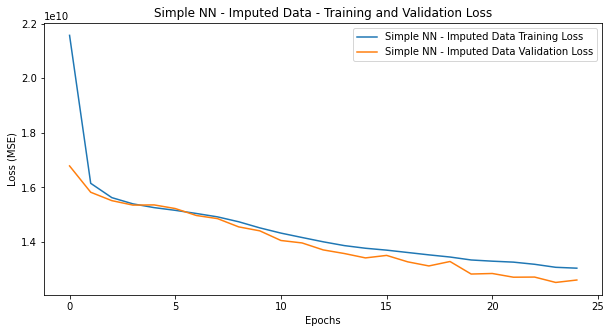


--- Simple NN - Imputed Data Test Set Evaluation ---
Average Test Loss (MSE): 12364484658.8270
Mean Absolute Error (MAE): 66054.0312
R-squared (R2): 0.4961


In [30]:
input_features_imputed = X_train_imputed_tensor.shape[1] 
model_sff_imputed = PricePredictorNN(input_features_imputed).to(device)

learning_rate_sff_imputed = 0.001 
optimizer_sff_imputed = optim.Adam(model_sff_imputed.parameters(), lr=learning_rate_sff_imputed)
criterion = nn.MSELoss() 
num_epochs_sff = 25 # You can adjust this

# Train and evaluate
model_sff_imputed = train_evaluate_model(
    model_sff_imputed, 
    train_loader_imputed, 
    val_loader_imputed, 
    test_loader_imputed,
    criterion, 
    optimizer_sff_imputed, 
    device, 
    num_epochs_sff, 
    model_name="Simple NN - Imputed Data"
)

#### 2. Simple Feedforward NN with Dropped Data

--- Training Simple NN - Dropped Data ---
Epoch [1/25], Train Loss: 25241471269.2206, Val Loss: 21093716961.1383
Epoch [2/25], Train Loss: 17841939762.6374, Val Loss: 16488293073.4545
Epoch [3/25], Train Loss: 15987806335.3508, Val Loss: 15376702007.6522
Epoch [4/25], Train Loss: 15257718975.9459, Val Loss: 14912568954.4348
Epoch [5/25], Train Loss: 14878888060.6458, Val Loss: 14628732136.7273
Epoch [6/25], Train Loss: 14734263989.0178, Val Loss: 14538746226.3399
Epoch [7/25], Train Loss: 14644502054.3026, Val Loss: 14437817078.8933
Epoch [8/25], Train Loss: 14522357854.5664, Val Loss: 14380568659.9842
Epoch [9/25], Train Loss: 14439166675.5300, Val Loss: 14223998781.7233
Epoch [10/25], Train Loss: 14368738017.6500, Val Loss: 14106238323.3518
Epoch [11/25], Train Loss: 14298519714.6238, Val Loss: 14042276767.8735
Epoch [12/25], Train Loss: 14210957971.2595, Val Loss: 13928031781.4387
Epoch [13/25], Train Loss: 14126628424.8183, Val Loss: 13805037396.9960
Epoch [14/25], Train Loss: 1400

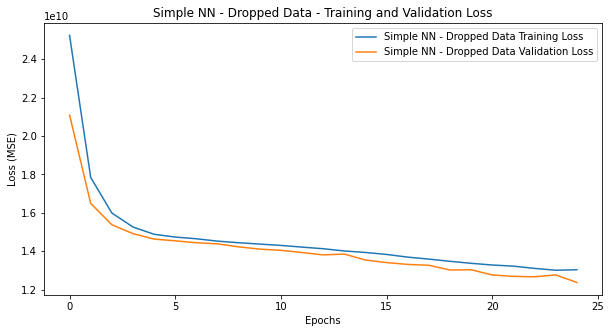


--- Simple NN - Dropped Data Test Set Evaluation ---
Average Test Loss (MSE): 12332061700.0394
Mean Absolute Error (MAE): 64324.2188
R-squared (R2): 0.4745


In [31]:
input_features_dropped = X_train_dropped_tensor.shape[1] 
model_sff_dropped = PricePredictorNN(input_features_dropped).to(device)

learning_rate_sff_dropped = 0.001
optimizer_sff_dropped = optim.Adam(model_sff_dropped.parameters(), lr=learning_rate_sff_dropped)
criterion = nn.MSELoss() 
num_epochs_sff = 25 # Can use the same number of epochs or adjust

# Train and evaluate
model_sff_dropped = train_evaluate_model(
    model_sff_dropped,
    train_loader_dropped,
    val_loader_dropped,
    test_loader_dropped,
    criterion,
    optimizer_sff_dropped,
    device,
    num_epochs_sff, # Using same num_epochs as above, or adjust
    model_name="Simple NN - Dropped Data"
)

#### 3+1. Setup for Embedding Neural Network

In [32]:
# --- Setup for Neural Network with Embeddings ---

# PricePredictorNNWithEmbeddings class definition
class PricePredictorNNWithEmbeddings(nn.Module):
    def __init__(self, num_numerical_ohe_features, 
                 num_makes, make_embedding_dim,
                 num_titles, title_embedding_dim):
        super(PricePredictorNNWithEmbeddings, self).__init__()
        
        self.make_embedding = nn.Embedding(num_makes, make_embedding_dim)
        self.title_embedding = nn.Embedding(num_titles, title_embedding_dim)
        
        total_input_features = num_numerical_ohe_features + make_embedding_dim + title_embedding_dim
        
        self.layer_1 = nn.Linear(total_input_features, 128) 
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.layer_2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.output_layer = nn.Linear(64, 1)

    def forward(self, x_numerical_ohe, x_make_ids, x_title_ids):
        embedded_make = self.make_embedding(x_make_ids)
        embedded_title = self.title_embedding(x_title_ids)
        x = torch.cat([x_numerical_ohe, embedded_make, embedded_title], dim=1)
        
        x = self.layer_1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.layer_2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output_layer(x)
        return x

# Parameters for IMPUTED data embeddings
# Ensure le_make_imputed and le_car_title_imputed are your fitted LabelEncoders
num_makes_imputed = len(le_make_imputed.classes_) 
num_titles_imputed = len(le_car_title_imputed.classes_)
make_embedding_dim_imputed = min(50, num_makes_imputed // 2) if num_makes_imputed > 1 else 1
title_embedding_dim_imputed = min(100, num_titles_imputed // 2) if num_titles_imputed > 1 else 1

print(f"Imputed Path - Vocab Size Makes: {num_makes_imputed}, Embedding Dim: {make_embedding_dim_imputed}")
print(f"Imputed Path - Vocab Size Titles: {num_titles_imputed}, Embedding Dim: {title_embedding_dim_imputed}")

# Get column indices for IMPUTED data
# Ensure X_train_imputed_processed is your DataFrame AFTER ColumnTransformer
feature_names_imputed = X_train_imputed_processed.columns.tolist()
make_encoded_idx_imputed = -1
title_encoded_idx_imputed = -1
try:
    make_encoded_idx_imputed = feature_names_imputed.index('le_passthrough__make_encoded')
    title_encoded_idx_imputed = feature_names_imputed.index('le_passthrough__car_title_encoded')
    num_other_features_imputed = X_train_imputed_processed.shape[1] - 2
except ValueError:
    print("ERROR: 'le_passthrough__make_encoded' or 'le_passthrough__car_title_encoded' not found in X_train_imputed_processed columns.")
    num_other_features_imputed = X_train_imputed_processed.shape[1] # Fallback, but investigate if error occurs

print(f"Imputed - Make Encoded Index: {make_encoded_idx_imputed}")
print(f"Imputed - Title Encoded Index: {title_encoded_idx_imputed}")
print(f"Imputed - Num other (num/OHE) features: {num_other_features_imputed}")


# Parameters for DROPPED data embeddings
# Ensure le_make_dropped and le_car_title_dropped are your fitted LabelEncoders
num_makes_dropped = len(le_make_dropped.classes_)
num_titles_dropped = len(le_car_title_dropped.classes_)
make_embedding_dim_dropped = min(50, num_makes_dropped // 2) if num_makes_dropped > 1 else 1
title_embedding_dim_dropped = min(100, num_titles_dropped // 2) if num_titles_dropped > 1 else 1

print(f"\nDropped Path - Vocab Size Makes: {num_makes_dropped}, Embedding Dim: {make_embedding_dim_dropped}")
print(f"Dropped Path - Vocab Size Titles: {num_titles_dropped}, Embedding Dim: {title_embedding_dim_dropped}")

# Get column indices for DROPPED data
# Ensure X_train_dropped_processed is your DataFrame AFTER ColumnTransformer
feature_names_dropped = X_train_dropped_processed.columns.tolist()
make_encoded_idx_dropped = -1
title_encoded_idx_dropped = -1
try:
    make_encoded_idx_dropped = feature_names_dropped.index('le_passthrough__make_encoded')
    title_encoded_idx_dropped = feature_names_dropped.index('le_passthrough__car_title_encoded')
    num_other_features_dropped = X_train_dropped_processed.shape[1] - 2
except ValueError:
    print("ERROR: 'le_passthrough__make_encoded' or 'le_passthrough__car_title_encoded' not found in X_train_dropped_processed columns.")
    num_other_features_dropped = X_train_dropped_processed.shape[1] # Fallback

print(f"Dropped - Make Encoded Index: {make_encoded_idx_dropped}")
print(f"Dropped - Title Encoded Index: {title_encoded_idx_dropped}")
print(f"Dropped - Num other (num/OHE) features: {num_other_features_dropped}")

Imputed Path - Vocab Size Makes: 110, Embedding Dim: 50
Imputed Path - Vocab Size Titles: 1353, Embedding Dim: 100
Imputed - Make Encoded Index: 97
Imputed - Title Encoded Index: 98
Imputed - Num other (num/OHE) features: 97

Dropped Path - Vocab Size Makes: 93, Embedding Dim: 46
Dropped Path - Vocab Size Titles: 1117, Embedding Dim: 100
Dropped - Make Encoded Index: 50
Dropped - Title Encoded Index: 51
Dropped - Num other (num/OHE) features: 50


#### 3. Embedding NN with Imputed Data

--- Training Embedding NN - Imputed Data ---
Epoch [1/25], Train Loss: 13686380876.3851, Val Loss: 9356125268.4007
Epoch [2/25], Train Loss: 8792273007.9031, Val Loss: 8217664513.1658
Epoch [3/25], Train Loss: 8131647213.4036, Val Loss: 7748914908.9107
Epoch [4/25], Train Loss: 7829688404.4335, Val Loss: 7487603670.4991
Epoch [5/25], Train Loss: 7629621755.0760, Val Loss: 7320972924.1530
Epoch [6/25], Train Loss: 7494931254.4644, Val Loss: 7194754513.0200
Epoch [7/25], Train Loss: 7376362612.3273, Val Loss: 7088941705.2095
Epoch [8/25], Train Loss: 7254722316.3851, Val Loss: 6997113036.9982
Epoch [9/25], Train Loss: 7182619340.8225, Val Loss: 6928533681.8361
Epoch [10/25], Train Loss: 7086834833.3466, Val Loss: 6851835164.7359
Epoch [11/25], Train Loss: 7064561445.7301, Val Loss: 6830160290.3898
Epoch [12/25], Train Loss: 7004694445.1162, Val Loss: 6771304596.6339
Epoch [13/25], Train Loss: 6959775511.8703, Val Loss: 6738311523.3224
Epoch [14/25], Train Loss: 6916040515.7555, Val Loss:

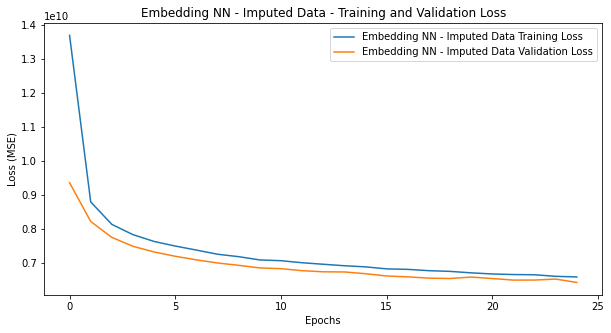


--- Embedding NN - Imputed Data Test Set Evaluation ---
Average Test Loss (MSE): 6369942177.1658
Mean Absolute Error (MAE): 36543.3477
R-squared (R2): 0.7404


In [33]:
# --- Scenario 3: Embedding NN - Imputed Data ---

# Create new TensorDatasets and DataLoaders for IMPUTED data with embeddings
# Ensure X_train_imputed_tensor, y_train (for y_train_imputed_tensor), etc. are available
# and make_encoded_idx_imputed, title_encoded_idx_imputed are correctly defined above.

if make_encoded_idx_imputed != -1 and title_encoded_idx_imputed != -1 :
    numerical_ohe_indices_imputed = [i for i in range(X_train_imputed_tensor.shape[1]) 
                                     if i not in [make_encoded_idx_imputed, title_encoded_idx_imputed]]

    X_train_num_ohe_imputed = X_train_imputed_tensor[:, numerical_ohe_indices_imputed]
    X_train_make_ids_imputed = X_train_imputed_tensor[:, make_encoded_idx_imputed].long()
    X_train_title_ids_imputed = X_train_imputed_tensor[:, title_encoded_idx_imputed].long()

    X_val_num_ohe_imputed = X_val_imputed_tensor[:, numerical_ohe_indices_imputed]
    X_val_make_ids_imputed = X_val_imputed_tensor[:, make_encoded_idx_imputed].long()
    X_val_title_ids_imputed = X_val_imputed_tensor[:, title_encoded_idx_imputed].long()

    X_test_num_ohe_imputed = X_test_imputed_tensor[:, numerical_ohe_indices_imputed]
    X_test_make_ids_imputed = X_test_imputed_tensor[:, make_encoded_idx_imputed].long()
    X_test_title_ids_imputed = X_test_imputed_tensor[:, title_encoded_idx_imputed].long()

    train_dataset_imputed_emb = TensorDataset(
        X_train_num_ohe_imputed, X_train_make_ids_imputed, X_train_title_ids_imputed, y_train_imputed_tensor
    )
    val_dataset_imputed_emb = TensorDataset(
        X_val_num_ohe_imputed, X_val_make_ids_imputed, X_val_title_ids_imputed, y_val_imputed_tensor
    )
    test_dataset_imputed_emb = TensorDataset(
        X_test_num_ohe_imputed, X_test_make_ids_imputed, X_test_title_ids_imputed, y_test_imputed_tensor
    )

    train_loader_imputed_emb = DataLoader(dataset=train_dataset_imputed_emb, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_imputed_emb = DataLoader(dataset=val_dataset_imputed_emb, batch_size=BATCH_SIZE, shuffle=False)
    test_loader_imputed_emb = DataLoader(dataset=test_dataset_imputed_emb, batch_size=BATCH_SIZE, shuffle=False)

    # Instantiate Embedding Model for Imputed Data
    model_emb_imputed = PricePredictorNNWithEmbeddings(
        num_numerical_ohe_features=num_other_features_imputed,
        num_makes=num_makes_imputed, 
        make_embedding_dim=make_embedding_dim_imputed,
        num_titles=num_titles_imputed, 
        title_embedding_dim=title_embedding_dim_imputed
    ).to(device)

    learning_rate_emb_imputed = 0.001
    optimizer_emb_imputed = optim.Adam(model_emb_imputed.parameters(), lr=learning_rate_emb_imputed)
    num_epochs_emb = 25 # You can adjust

    model_emb_imputed = train_evaluate_model(
        model_emb_imputed,
        train_loader_imputed_emb,
        val_loader_imputed_emb,
        test_loader_imputed_emb,
        criterion, # Assuming same MSELoss
        optimizer_emb_imputed,
        device,
        num_epochs_emb,
        model_name="Embedding NN - Imputed Data"
    )
else:
    print("Skipping Embedding NN for Imputed Data due to column index error.")


#### 4. Embedding NN with Dropped Data

--- Training Embedding NN - Dropped Data ---
Epoch [1/25], Train Loss: 17553530848.9467, Val Loss: 12451405857.8972
Epoch [2/25], Train Loss: 11084396039.7363, Val Loss: 10033869818.4348
Epoch [3/25], Train Loss: 9511120124.2130, Val Loss: 8986991176.8538
Epoch [4/25], Train Loss: 8828570059.6855, Val Loss: 8475963875.9209
Epoch [5/25], Train Loss: 8434530673.2308, Val Loss: 8165978144.8854
Epoch [6/25], Train Loss: 8226148513.0549, Val Loss: 7934829449.8656
Epoch [7/25], Train Loss: 8063749937.3931, Val Loss: 7748524208.0632
Epoch [8/25], Train Loss: 7926578933.0719, Val Loss: 7627009666.0237
Epoch [9/25], Train Loss: 7803935246.4987, Val Loss: 7542103974.4506
Epoch [10/25], Train Loss: 7717657708.3077, Val Loss: 7418440004.8063
Epoch [11/25], Train Loss: 7615221503.2426, Val Loss: 7325038978.2767
Epoch [12/25], Train Loss: 7517661022.1606, Val Loss: 7255684648.4743
Epoch [13/25], Train Loss: 7463153549.9036, Val Loss: 7170231912.9802
Epoch [14/25], Train Loss: 7373107270.7625, Val Lo

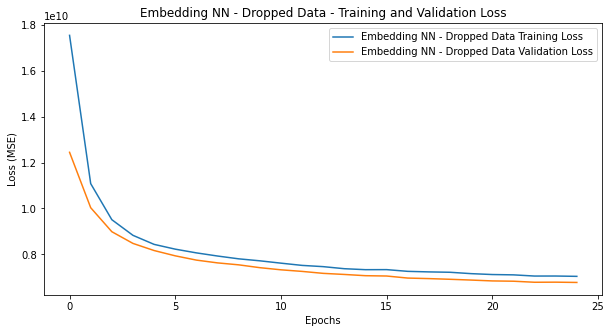


--- Embedding NN - Dropped Data Test Set Evaluation ---
Average Test Loss (MSE): 6613049627.8343
Mean Absolute Error (MAE): 37240.4609
R-squared (R2): 0.7182


In [34]:
# --- Scenario 4: Embedding NN - Dropped Data ---

# Create new TensorDatasets and DataLoaders for DROPPED data with embeddings
# Ensure X_train_dropped_tensor, y_train_dropped (for y_train_dropped_tensor), etc. are available
# and make_encoded_idx_dropped, title_encoded_idx_dropped are correctly defined.

if make_encoded_idx_dropped != -1 and title_encoded_idx_dropped != -1:
    numerical_ohe_indices_dropped = [i for i in range(X_train_dropped_tensor.shape[1])
                                     if i not in [make_encoded_idx_dropped, title_encoded_idx_dropped]]

    X_train_num_ohe_dropped = X_train_dropped_tensor[:, numerical_ohe_indices_dropped]
    X_train_make_ids_dropped = X_train_dropped_tensor[:, make_encoded_idx_dropped].long()
    X_train_title_ids_dropped = X_train_dropped_tensor[:, title_encoded_idx_dropped].long()

    X_val_num_ohe_dropped = X_val_dropped_tensor[:, numerical_ohe_indices_dropped]
    X_val_make_ids_dropped = X_val_dropped_tensor[:, make_encoded_idx_dropped].long()
    X_val_title_ids_dropped = X_val_dropped_tensor[:, title_encoded_idx_dropped].long()

    X_test_num_ohe_dropped = X_test_dropped_tensor[:, numerical_ohe_indices_dropped]
    X_test_make_ids_dropped = X_test_dropped_tensor[:, make_encoded_idx_dropped].long()
    X_test_title_ids_dropped = X_test_dropped_tensor[:, title_encoded_idx_dropped].long()

    train_dataset_dropped_emb = TensorDataset(
        X_train_num_ohe_dropped, X_train_make_ids_dropped, X_train_title_ids_dropped, y_train_dropped_tensor
    )
    val_dataset_dropped_emb = TensorDataset(
        X_val_num_ohe_dropped, X_val_make_ids_dropped, X_val_title_ids_dropped, y_val_dropped_tensor
    )
    test_dataset_dropped_emb = TensorDataset(
        X_test_num_ohe_dropped, X_test_make_ids_dropped, X_test_title_ids_dropped, y_test_dropped_tensor
    )

    train_loader_dropped_emb = DataLoader(dataset=train_dataset_dropped_emb, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_dropped_emb = DataLoader(dataset=val_dataset_dropped_emb, batch_size=BATCH_SIZE, shuffle=False)
    test_loader_dropped_emb = DataLoader(dataset=test_dataset_dropped_emb, batch_size=BATCH_SIZE, shuffle=False)

    # Instantiate Embedding Model for Dropped Data
    model_emb_dropped = PricePredictorNNWithEmbeddings(
        num_numerical_ohe_features=num_other_features_dropped,
        num_makes=num_makes_dropped,
        make_embedding_dim=make_embedding_dim_dropped,
        num_titles=num_titles_dropped,
        title_embedding_dim=title_embedding_dim_dropped
    ).to(device)

    learning_rate_emb_dropped = 0.001
    optimizer_emb_dropped = optim.Adam(model_emb_dropped.parameters(), lr=learning_rate_emb_dropped)
    num_epochs_emb = 25 # Can use the same or adjust

    model_emb_dropped = train_evaluate_model(
        model_emb_dropped,
        train_loader_dropped_emb,
        val_loader_dropped_emb,
        test_loader_dropped_emb,
        criterion, # Assuming same MSELoss
        optimizer_emb_dropped,
        device,
        num_epochs_emb, # Using same num_epochs as above, or adjust
        model_name="Embedding NN - Dropped Data"
    )
else:
    print("Skipping Embedding NN for Dropped Data due to column index error.")

## Hyperparameter Tune - Find The Best Achievable

As seen previously `Embedding NN - Imputed Data` seemed to do the best of all, so we may try and do a little hyperparameter tuning on this, to see if we can get a better result.

In [39]:
import itertools

class TunablePricePredictorNNWithEmbeddings(nn.Module):
    def __init__(self, num_numerical_ohe_features, 
                 num_makes, make_embedding_dim,
                 num_titles, title_embedding_dim,
                 dense_layers_config, # List of tuples: (out_features, dropout_p)
                 ):
        super().__init__()
        self.make_embedding = nn.Embedding(num_makes, make_embedding_dim)
        self.title_embedding = nn.Embedding(num_titles, title_embedding_dim)
        
        current_in_features = num_numerical_ohe_features + make_embedding_dim + title_embedding_dim
        
        self.dense_layers = nn.ModuleList()
        for i, (out_features, dropout_p) in enumerate(dense_layers_config):
            self.dense_layers.append(nn.Linear(current_in_features, out_features))
            self.dense_layers.append(nn.ReLU())
            if dropout_p > 0: # Only add dropout if p > 0
                self.dense_layers.append(nn.Dropout(dropout_p))
            current_in_features = out_features # Input for next layer
            
        self.output_layer = nn.Linear(current_in_features, 1) # Output layer

    def forward(self, x_numerical_ohe, x_make_ids, x_title_ids):
        embedded_make = self.make_embedding(x_make_ids)
        embedded_title = self.title_embedding(x_title_ids)
        x = torch.cat([x_numerical_ohe, embedded_make, embedded_title], dim=1)
        
        for layer in self.dense_layers:
            x = layer(x)
            
        x = self.output_layer(x)
        return x
    
def tune_embedding_nn_imputed_v2(
    train_loader, val_loader, test_loader, 
    num_numerical_ohe_features, 
    num_makes, 
    num_titles,
    criterion, 
    device, 
    base_num_epochs):

    # --- Define Hyperparameter Ranges to Test ---
    learning_rates_to_try = [1e-3, 5e-4] 
    make_emb_dims_to_try = [min(30, num_makes // 2) if num_makes > 1 else 1, 
                            min(50, num_makes // 2) if num_makes > 1 else 1]
    title_emb_dims_to_try = [min(100, num_titles // 2) if num_titles > 1 else 1]
    
    # Dense layer configurations: list of lists, where each inner list is [(out_features, dropout_p), ...]
    dense_configs_to_try = [
        [(256, 0.3), (128, 0.2)],                                 # 2 layers, larger
        [(128, 0.3), (64, 0.2), (32, 0.1)],                       # 3 layers
        [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1)]            # 4 layers (can be slow)
    ]

    best_val_r2 = -float('inf') # Track best R2 on validation set to choose final model params
    best_config_on_val = {}
    results_log = []

    param_combinations = list(itertools.product(
        learning_rates_to_try,
        make_emb_dims_to_try,
        title_emb_dims_to_try,
        dense_configs_to_try  # Now iterating through dense_configs
    ))

    print(f"Starting hyperparameter tuning v2 for {len(param_combinations)} configurations...\n")

    for i, (lr, make_emb_dim, title_emb_dim, dense_config) in enumerate(param_combinations):
        
        current_config_str = (
            f"Config {i+1}/{len(param_combinations)} - LR: {lr}, MakeEmb: {make_emb_dim}, TitleEmb: {title_emb_dim}, "
            f"DenseLayers: {dense_config}"
        )
        print(f"--- Testing: {current_config_str} ---")
        
        current_model = TunablePricePredictorNNWithEmbeddings(
            num_numerical_ohe_features=num_numerical_ohe_features,
            num_makes=num_makes, 
            make_embedding_dim=make_emb_dim,
            num_titles=num_titles, 
            title_embedding_dim=title_emb_dim,
            dense_layers_config=dense_config
        ).to(device)
        
        current_optimizer = optim.Adam(current_model.parameters(), lr=lr)
        
        # --- Simplified Training & Validation for Tuning ---
        current_best_epoch_val_r2 = -float('inf') # Track R2 on val set for this config

        for epoch in range(base_num_epochs):
            current_model.train()
            epoch_train_loss = 0.0
            for batch_data_tune in train_loader:
                features_num_ohe, features_make_ids, features_title_ids, labels = batch_data_tune
                features_num_ohe,features_make_ids,features_title_ids,labels = features_num_ohe.to(device),features_make_ids.to(device),features_title_ids.to(device),labels.to(device)
                outputs = current_model(features_num_ohe, features_make_ids, features_title_ids)
                loss = criterion(outputs, labels)
                current_optimizer.zero_grad(); loss.backward(); current_optimizer.step()
                epoch_train_loss +=loss.item()
            
            current_model.eval()
            current_val_loss_epoch = 0.0
            current_val_preds = []
            current_val_labels = []
            with torch.no_grad():
                for batch_data_tune_val in val_loader:
                    features_num_ohe, features_make_ids, features_title_ids, labels = batch_data_tune_val
                    features_num_ohe,features_make_ids,features_title_ids,labels = features_num_ohe.to(device),features_make_ids.to(device),features_title_ids.to(device),labels.to(device)
                    outputs = current_model(features_num_ohe, features_make_ids, features_title_ids)
                    loss = criterion(outputs, labels)
                    current_val_loss_epoch += loss.item()
                    current_val_preds.extend(outputs.cpu().numpy())
                    current_val_labels.extend(labels.cpu().numpy())
            
            avg_val_loss_tune = current_val_loss_epoch / len(val_loader)
            r2_val_epoch = r2_score(current_val_labels, current_val_preds)
            
            if (epoch + 1) % 5 == 0 : 
                 print(f"Epoch [{epoch+1}/{base_num_epochs}], Val Loss: {avg_val_loss_tune:.4f}, Val R2: {r2_val_epoch:.4f}")
            
            # Early stopping for this config if val R2 doesn't improve for a few epochs (optional)
            # Or simply take the R2 from the last epoch for this config
            if epoch == base_num_epochs -1: # Last epoch's R2
                 current_config_val_r2 = r2_val_epoch


        # Store results based on validation performance for this config
        # (Here, we just use the last epoch's validation R2 for simplicity, 
        #  in practice you might save the model that gave the best val R2 during its epochs)
        
        print(f"Config Validation R2 (last epoch): {current_config_val_r2:.4f}\n")
        
        log_entry = {
            'lr': lr, 'make_emb_dim': make_emb_dim, 'title_emb_dim': title_emb_dim,
            'dense_config': dense_config, 'Val_R2_last_epoch': current_config_val_r2
        }
        results_log.append(log_entry)

        if current_config_val_r2 > best_val_r2:
            best_val_r2 = current_config_val_r2
            best_config_on_val = log_entry
            # Optionally save this model's state_dict if it's the best so far on validation
            # torch.save(current_model.state_dict(), 'best_tuning_model.pth')


    print("\n--- Hyperparameter Tuning v2 Complete ---")
    print("Logged Results (based on last epoch val R2):")
    for res in sorted(results_log, key=lambda x: x['Val_R2_last_epoch'], reverse=True): # Sort by best Val R2
        print(res)
    
    print("\nBest Configuration Found (based on last epoch val R2):")
    print(best_config_on_val)
    
    # Now, you would typically re-train a new model from scratch using the best_config_on_val
    # for the full number of epochs (or more, with early stopping on val set)
    # and then evaluate THAT final model on the test set ONCE.
    
    print("\n--- Evaluating Best Config on Test Set ---")
    if best_config_on_val:
        best_lr = best_config_on_val['lr']
        best_make_emb = best_config_on_val['make_emb_dim']
        best_title_emb = best_config_on_val['title_emb_dim']
        best_dense_cfg = best_config_on_val['dense_config']

        final_model = TunablePricePredictorNNWithEmbeddings(
            num_numerical_ohe_features=num_numerical_ohe_features,
            num_makes=num_makes, make_embedding_dim=best_make_emb,
            num_titles=num_titles, title_embedding_dim=best_title_emb,
            dense_layers_config=best_dense_cfg
        ).to(device)
        final_optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
        
        # Train the final best model (can use more epochs here)
        print("Training final best model...")
        # Using the full train_evaluate_model for the final run
        train_evaluate_model(
            final_model, train_loader, val_loader, test_loader, 
            criterion, final_optimizer, device, 
            num_epochs=base_num_epochs + 10, # Example: train for a bit longer
            model_name="Final Best Tuned Model",
            is_tuning=False # Ensure plotting and full prints
        )
    else:
        print("No best configuration found to evaluate on test set.")

    return best_config_on_val, results_log

In [40]:
best_hyperparams_v2, all_run_results_v2 = tune_embedding_nn_imputed_v2(
    train_loader=train_loader_imputed_emb, 
    val_loader=val_loader_imputed_emb, 
    test_loader=test_loader_imputed_emb, # Test loader is used for final eval of best config
    num_numerical_ohe_features=num_other_features_imputed,
    num_makes=num_makes_imputed,
    num_titles=num_titles_imputed,
    criterion=criterion, 
    device=device,
    base_num_epochs=10 # Fewer epochs for each tuning trial
)

Starting hyperparameter tuning v2 for 12 configurations...

--- Testing: Config 1/12 - LR: 0.001, MakeEmb: 30, TitleEmb: 100, DenseLayers: [(256, 0.3), (128, 0.2)] ---
Epoch [5/10], Val Loss: 7039880053.1585, Val R2: 0.7195
Epoch [10/10], Val Loss: 6678742594.9144, Val R2: 0.7339
Config Validation R2 (last epoch): 0.7339

--- Testing: Config 2/12 - LR: 0.001, MakeEmb: 30, TitleEmb: 100, DenseLayers: [(128, 0.3), (64, 0.2), (32, 0.1)] ---
Epoch [5/10], Val Loss: 6745836575.9417, Val R2: 0.7312
Epoch [10/10], Val Loss: 6477804309.6831, Val R2: 0.7419
Config Validation R2 (last epoch): 0.7419

--- Testing: Config 3/12 - LR: 0.001, MakeEmb: 30, TitleEmb: 100, DenseLayers: [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1)] ---
Epoch [5/10], Val Loss: 6483009734.9945, Val R2: 0.7418
Epoch [10/10], Val Loss: 6178952839.8106, Val R2: 0.7539
Config Validation R2 (last epoch): 0.7539

--- Testing: Config 4/12 - LR: 0.001, MakeEmb: 50, TitleEmb: 100, DenseLayers: [(256, 0.3), (128, 0.2)] ---
Epoch [5

TypeError: train_evaluate_model() got an unexpected keyword argument 'is_tuning'

This did go through until the last step and failed, but we don't have the resources to rerun it, so I will manually take the result:

```text
{'lr': 0.001, 'make_emb_dim': 30, 'title_emb_dim': 100, 'dense_config': [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1)], 'Val_R2_last_epoch': 0.7538982473757531}
```

As visible, the more layers, the better our results got generally, let's explore this a bit further with a 5 layer one.


--- Testing 5-Layer Configuration ---
--- Training 5-Layer Embedding NN - Imputed ---
Epoch [1/20], Train Loss: 9661008048.7280, Val Loss: 7310933145.5883
Epoch [2/20], Train Loss: 7840009987.3618, Val Loss: 7063792897.8652
Epoch [3/20], Train Loss: 7578752094.1316, Val Loss: 6880261188.0801
Epoch [4/20], Train Loss: 7461680356.7928, Val Loss: 6788331914.6084
Epoch [5/20], Train Loss: 7308284637.8692, Val Loss: 6485390943.3005
Epoch [6/20], Train Loss: 7203785587.6274, Val Loss: 6528130701.2896
Epoch [7/20], Train Loss: 7092769053.2568, Val Loss: 6334361527.1403
Epoch [8/20], Train Loss: 7027063068.5569, Val Loss: 6311161004.3570
Epoch [9/20], Train Loss: 6944109693.4005, Val Loss: 6221530349.2896
Epoch [10/20], Train Loss: 6873981272.4577, Val Loss: 6246257637.1293
Epoch [11/20], Train Loss: 6797133019.8946, Val Loss: 6250154062.8634
Epoch [12/20], Train Loss: 6778651569.6528, Val Loss: 6100995045.4791
Epoch [13/20], Train Loss: 6672897798.6112, Val Loss: 6364380425.0929
Epoch [14/20

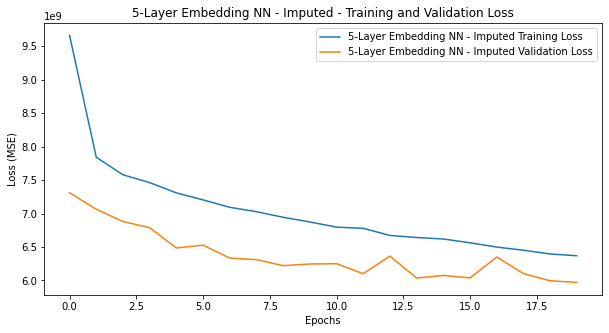


--- 5-Layer Embedding NN - Imputed Test Set Evaluation ---
Average Test Loss (MSE): 5997854084.2550
Mean Absolute Error (MAE): 35012.6914
R-squared (R2): 0.7556


In [42]:
lr_deeper = 0.001
make_emb_dim_deeper = 30 
title_emb_dim_deeper = 100
dense_config_5_layers = [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1), (16, 0.1)] 
num_epochs_deeper_test = 20 # Train for a bit longer to see

model_5_layer = TunablePricePredictorNNWithEmbeddings(
    num_numerical_ohe_features=num_other_features_imputed, # From your setup
    num_makes=num_makes_imputed,                            # From your setup
    make_embedding_dim=make_emb_dim_deeper,
    num_titles=num_titles_imputed,                          # From your setup
    title_embedding_dim=title_emb_dim_deeper,
    dense_layers_config=dense_config_5_layers
).to(device)

optimizer_5_layer = optim.Adam(model_5_layer.parameters(), lr=lr_deeper)

print("--- Testing 5-Layer Configuration ---")
# Ensure train_loader_imputed_emb, val_loader_imputed_emb, test_loader_imputed_emb are defined
trained_model_5_layer = train_evaluate_model(
    model_5_layer,
    train_loader_imputed_emb, # Use the correct loader for imputed data with embeddings
    val_loader_imputed_emb,
    test_loader_imputed_emb,
    criterion, # Your defined criterion (e.g., nn.MSELoss())
    optimizer_5_layer,
    device,
    num_epochs_deeper_test,
    model_name="5-Layer Embedding NN - Imputed",
    is_tuning=False # Get full plots and prints for this specific test
)


--- Testing 6-Layer Configuration ---
--- Training 6-Layer Embedding NN - Imputed ---
Epoch [1/20], Train Loss: 10146816787.7711, Val Loss: 7374042405.1876
Epoch [2/20], Train Loss: 8461922547.9524, Val Loss: 6928306322.4189
Epoch [3/20], Train Loss: 8009403164.9568, Val Loss: 6833809282.3315
Epoch [4/20], Train Loss: 7893533699.7993, Val Loss: 6696147596.3570
Epoch [5/20], Train Loss: 7804927895.8703, Val Loss: 6519666808.0146
Epoch [6/20], Train Loss: 7640767752.6733, Val Loss: 6610338644.4007
Epoch [7/20], Train Loss: 7575830961.3654, Val Loss: 6525177723.2787
Epoch [8/20], Train Loss: 7469036464.0531, Val Loss: 6379094894.2222
Epoch [9/20], Train Loss: 7387500566.9455, Val Loss: 6241844283.3370
Epoch [10/20], Train Loss: 7332613195.1353, Val Loss: 6201288138.6667
Epoch [11/20], Train Loss: 7272764754.9088, Val Loss: 6168194570.3169
Epoch [12/20], Train Loss: 7253149002.9729, Val Loss: 6195342465.5738
Epoch [13/20], Train Loss: 7225451056.1031, Val Loss: 6113170380.2404
Epoch [14/20

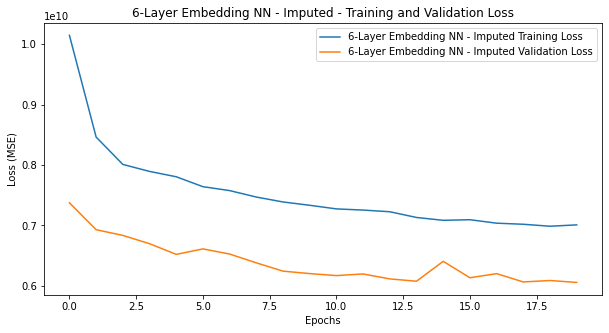


--- 6-Layer Embedding NN - Imputed Test Set Evaluation ---
Average Test Loss (MSE): 6085646187.5410
Mean Absolute Error (MAE): 36017.8906
R-squared (R2): 0.7520


In [44]:
# --- Configuration for a 5-Layer Test ---
lr_deeper = 0.001
make_emb_dim_deeper = 30 
title_emb_dim_deeper = 100
dense_config_6_layers = [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1), (16, 0.1), (8,0.1)] 
num_epochs_deeper_test = 20 # Train for a bit longer to see

model_6_layer = TunablePricePredictorNNWithEmbeddings(
    num_numerical_ohe_features=num_other_features_imputed, # From your setup
    num_makes=num_makes_imputed,                            # From your setup
    make_embedding_dim=make_emb_dim_deeper,
    num_titles=num_titles_imputed,                          # From your setup
    title_embedding_dim=title_emb_dim_deeper,
    dense_layers_config=dense_config_6_layers
).to(device)

optimizer_6_layer = optim.Adam(model_6_layer.parameters(), lr=lr_deeper)

print("--- Testing 6-Layer Configuration ---")
# Ensure train_loader_imputed_emb, val_loader_imputed_emb, test_loader_imputed_emb are defined
trained_model_6_layer = train_evaluate_model(
    model_6_layer,
    train_loader_imputed_emb, # Use the correct loader for imputed data with embeddings
    val_loader_imputed_emb,
    test_loader_imputed_emb,
    criterion, # Your defined criterion (e.g., nn.MSELoss())
    optimizer_6_layer,
    device,
    num_epochs_deeper_test,
    model_name="6-Layer Embedding NN - Imputed",
    is_tuning=False # Get full plots and prints for this specific test
)

We can see that the 6 layers did not perform better. Let's now try and run the 5 layer one from before a for 100 epochs and get our final model.

--- Training Final 5-Layer Model for More Epochs ---
--- Training Final 5-Layer Embedding NN (Extended Training) ---
Epoch [1/75], Train Loss: 9446146174.3128, Val Loss: 7142336049.7195
Epoch [2/75], Train Loss: 7730749019.7446, Val Loss: 6839200983.7814
Epoch [3/75], Train Loss: 7415928940.4913, Val Loss: 6605207444.6339
Epoch [4/75], Train Loss: 7256746424.0516, Val Loss: 6565219157.6248
Epoch [5/75], Train Loss: 7174209568.3687, Val Loss: 6412028494.6302
Epoch [6/75], Train Loss: 7058611183.7407, Val Loss: 6497684121.4135
Epoch [7/75], Train Loss: 6955934815.3189, Val Loss: 6285839702.7905
Epoch [8/75], Train Loss: 6834541034.1668, Val Loss: 6366319444.8670
Epoch [9/75], Train Loss: 6797922867.7649, Val Loss: 6229720814.8051
Epoch [10/75], Train Loss: 6774666060.3851, Val Loss: 6237619336.6849
Epoch [11/75], Train Loss: 6698699803.8071, Val Loss: 6241674340.5464
Epoch [12/75], Train Loss: 6623827123.5399, Val Loss: 6309403010.5064
Epoch [13/75], Train Loss: 6597928915.1838, Val Loss

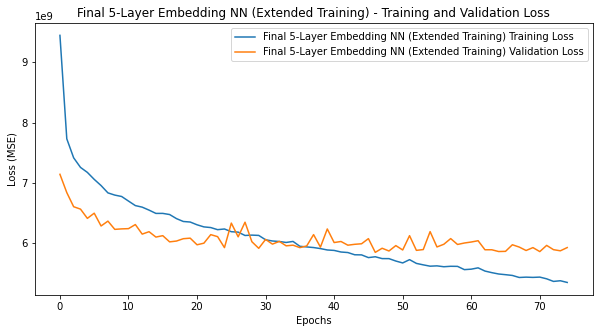


--- Final 5-Layer Embedding NN (Extended Training) Test Set Evaluation ---
Average Test Loss (MSE): 5886004206.0474
Mean Absolute Error (MAE): 34476.8203
R-squared (R2): 0.7601


In [47]:
best_lr_5_layer = 0.001
best_make_emb_dim_5_layer = 30
best_title_emb_dim_5_layer = 100
best_dense_config_5_layer = [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1), (16, 0.1)] 
num_epochs_final_training = 75

print("--- Training Final 5-Layer Model for More Epochs ---")

final_5_layer_model = TunablePricePredictorNNWithEmbeddings(
    num_numerical_ohe_features=num_other_features_imputed,
    num_makes=num_makes_imputed, 
    make_embedding_dim=best_make_emb_dim_5_layer,
    num_titles=num_titles_imputed, 
    title_embedding_dim=best_title_emb_dim_5_layer,
    dense_layers_config=best_dense_config_5_layer
).to(device)

final_5_layer_optimizer = optim.Adam(final_5_layer_model.parameters(), lr=best_lr_5_layer)

final_trained_5_layer_model = train_evaluate_model(
    final_5_layer_model,
    train_loader_imputed_emb,
    val_loader_imputed_emb,
    test_loader_imputed_emb,
    criterion, 
    final_5_layer_optimizer,
    device,
    num_epochs_final_training,
    model_name="Final 5-Layer Embedding NN (Extended Training)",
    is_tuning=False # Ensure full prints and plotting
)


The final R-squred seems to be better, but the model seems to have overfitted, let's check out the 4 layer model with 50 epochs, since that one seemed to have smoother loss curve.

--- Training Final 4-Layer Model for More Epochs ---
--- Training Final 4-Layer Embedding NN (Extended Training) ---
Epoch [1/50], Train Loss: 9301297905.4029, Val Loss: 7267099004.9690
Epoch [2/50], Train Loss: 7484646636.3038, Val Loss: 6832809419.1913
Epoch [3/50], Train Loss: 7211202214.5425, Val Loss: 6685880009.7341
Epoch [4/50], Train Loss: 7036318125.1037, Val Loss: 6604338542.1639
Epoch [5/50], Train Loss: 6934915062.6268, Val Loss: 6558273761.5155
Epoch [6/50], Train Loss: 6824317117.1880, Val Loss: 6429843938.9727
Epoch [7/50], Train Loss: 6712043353.9199, Val Loss: 6364050408.3352
Epoch [8/50], Train Loss: 6651701379.8742, Val Loss: 6345056554.4918
Epoch [9/50], Train Loss: 6597125744.7780, Val Loss: 6365455148.5902
Epoch [10/50], Train Loss: 6512163257.7137, Val Loss: 6193766063.0965
Epoch [11/50], Train Loss: 6462557177.0764, Val Loss: 6168485975.4317
Epoch [12/50], Train Loss: 6402497348.9115, Val Loss: 6114748908.7067
Epoch [13/50], Train Loss: 6376210395.8071, Val Loss

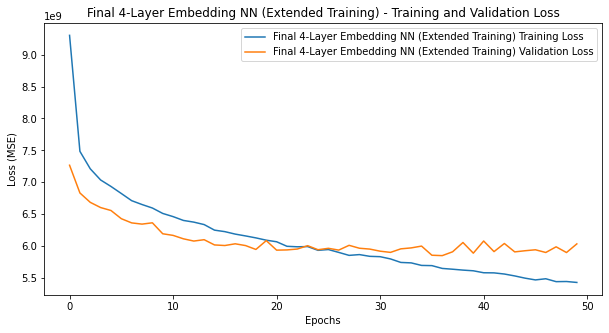


--- Final 4-Layer Embedding NN (Extended Training) Test Set Evaluation ---
Average Test Loss (MSE): 5982424144.7869
Mean Absolute Error (MAE): 34635.5000
R-squared (R2): 0.7562


In [48]:
best_lr_4_layer = 0.001
best_make_emb_dim_4_layer = 30
best_title_emb_dim_4_layer = 100
best_dense_config_4_layer = [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1)] 
num_epochs_final_training = 50

# {'lr': 0.001, 'make_emb_dim': 30, 'title_emb_dim': 100, 'dense_config': [(256, 0.3), (128, 0.2), (64, 0.2), (32, 0.1)], 'Val_R2_last_epoch': 0.7538982473757531}

print("--- Training Final 4-Layer Model for More Epochs ---")

final_4_layer_model = TunablePricePredictorNNWithEmbeddings(
    num_numerical_ohe_features=num_other_features_imputed,
    num_makes=num_makes_imputed, 
    make_embedding_dim=best_make_emb_dim_4_layer,
    num_titles=num_titles_imputed, 
    title_embedding_dim=best_title_emb_dim_4_layer,
    dense_layers_config=best_dense_config_4_layer
).to(device)

final_4_layer_optimizer = optim.Adam(final_4_layer_model.parameters(), lr=best_lr_4_layer)

final_trained_4_layer_model = train_evaluate_model(
    final_4_layer_model,
    train_loader_imputed_emb,
    val_loader_imputed_emb,
    test_loader_imputed_emb,
    criterion, 
    final_4_layer_optimizer,
    device,
    num_epochs_final_training,
    model_name="Final 4-Layer Embedding NN (Extended Training)",
    is_tuning=False # Ensure full prints and plotting
)


## Conclusion

We have successfully transformed our dataset into a format that is suitable for training a NN, found that imputing works better on this dataset and dense vector embedding of the features `make` and `car_title` improved the result. We also did some light hyperparameter tuning, finding that our starting parameters were roughly right and that the model could benefit from some additional hidden layers. In the end we chose to go with 5 hidden layers, then reran this easily achievable "optimal" model with 75 epochs to see how it would perform. It seemingly overfitted after 30 epochs and the loss curve was also incosistent, so we tried again with 4 layers and 50 epochs, but this did not yield a better result.

In the end the best result we got was:

```text
--- Final 5-Layer Embedding NN (Extended Training) Test Set Evaluation ---
Average Test Loss (MSE): 5886004206.0474
Mean Absolute Error (MAE): 34476.8203
R-squared (R2): 0.7601
```

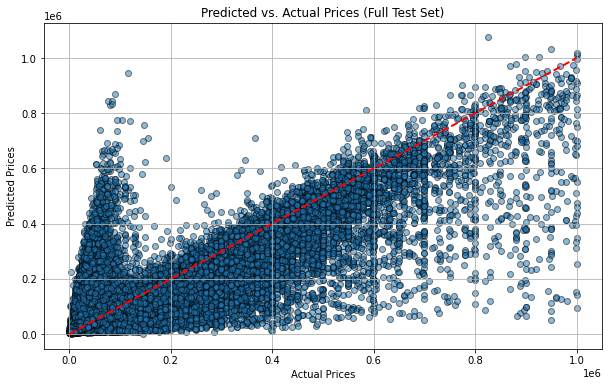

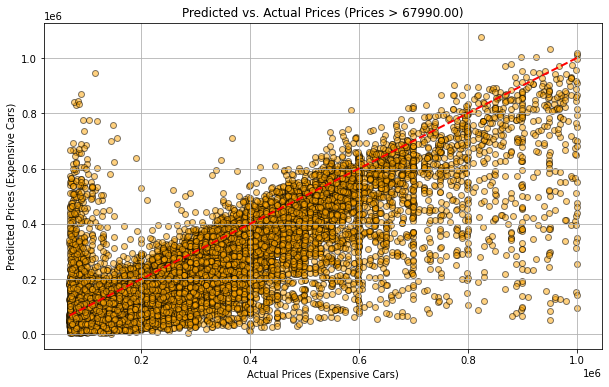

Expensive Cars Metrics: MAE = 84472.23, R-squared = 0.53


In [51]:
# Function to get predictions (as I suggested before)
def get_predictions(model, test_loader, device):
    model.eval()  # Set to evaluation mode
    all_preds = []
    all_actuals = []
    with torch.no_grad():
        for batch in test_loader:
            X_num_ohe, X_make_ids, X_title_ids, y_batch = batch  # Adjust based on your data loader
            X_num_ohe = X_num_ohe.to(device)
            X_make_ids = X_make_ids.to(device)
            X_title_ids = X_title_ids.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_num_ohe, X_make_ids, X_title_ids)  # Matches your embedding model
            all_preds.extend(outputs.cpu().numpy())
            all_actuals.extend(y_batch.cpu().numpy())
    return np.array(all_preds).flatten(), np.array(all_actuals).flatten()

# Get predictions using your final trained model
preds, actuals = get_predictions(final_trained_5_layer_model, test_loader_imputed_emb, device)

# Full test set plot
plt.figure(figsize=(10, 6))
plt.scatter(actuals, preds, alpha=0.5, edgecolor='k')
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs. Actual Prices (Full Test Set)')
plt.grid(True)
plt.show()

# Subset for expensive cars (e.g., top 25%)
price_threshold = np.percentile(actuals, 75)
expensive_indices = actuals > price_threshold
preds_expensive = preds[expensive_indices]
actuals_expensive = actuals[expensive_indices]

plt.figure(figsize=(10, 6))
plt.scatter(actuals_expensive, preds_expensive, alpha=0.5, edgecolor='k', color='orange')
plt.plot([actuals_expensive.min(), actuals_expensive.max()], [actuals_expensive.min(), actuals_expensive.max()], 'r--', lw=2)
plt.xlabel('Actual Prices (Expensive Cars)')
plt.ylabel('Predicted Prices (Expensive Cars)')
plt.title(f'Predicted vs. Actual Prices (Prices > {price_threshold:.2f})')
plt.grid(True)
plt.show()

# Print metrics for the subset
mae_expensive = mean_absolute_error(actuals_expensive, preds_expensive)
r2_expensive = r2_score(actuals_expensive, preds_expensive)
print(f"Expensive Cars Metrics: MAE = {mae_expensive:.2f}, R-squared = {r2_expensive:.2f}")

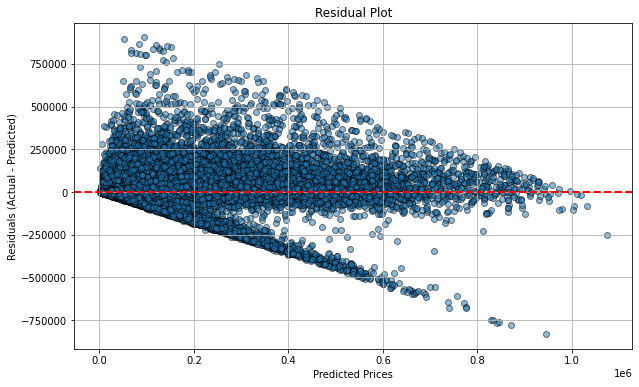

In [52]:
residuals = actuals - preds

plt.figure(figsize=(10, 6))
plt.scatter(preds, residuals, alpha=0.5, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', lw=2) # Line at zero residual
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

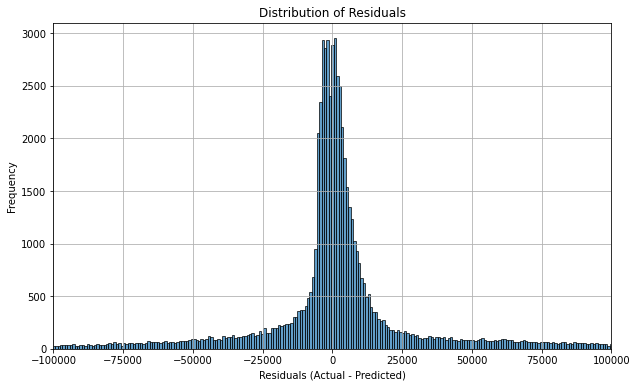

In [61]:
# Assuming 'residuals' are available from the previous step
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=2000, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True)
plt.xlim(-100000, 100000)
plt.show()

# For a smoother KDE plot (Kernel Density Estimate)
# import seaborn as sns
# plt.figure(figsize=(10, 6))
# sns.kdeplot(residuals, fill=True)
# plt.xlabel('Residuals (Actual - Predicted)')
# plt.title('KDE Plot of Residuals')
# plt.grid(True)
# plt.show()